# Credit Card Evaluation


In [10]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import average_precision_score, roc_auc_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier

In [11]:
RANDOM_STATE = 1337

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "padme" / "src" / "main" / "resources" / "data"
OUT_DIR = DATA_DIR / "output/credit_card"

TRAIN_PATH = DATA_DIR / "input" / "creditcard_train.csv"
TEST_PATH = OUT_DIR / "creditcard_test.csv"

MODES = ["baseline", "padme", "random"]

NODES = 5
BASELINE_NODE = 0

RATIOS = [0.02, 0.03, 0.04, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

DROP_COLS = ["__id", "label", "Time"]
LABEL_COL = "label"


In [12]:
def ratio_to_int(r: float) -> int:
    return int(round(r * 100))

def load_csv_any(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Not found: {path}")
    return pd.read_csv(path)

def load_test(train_csv: Path, test_csv: Path):
    if not test_csv.exists():
        raise FileNotFoundError(f"Required test set not found: {test_csv}. ")

    df_train = load_csv_any(train_csv)
    df_test = load_csv_any(test_csv)

    y_train = df_train[LABEL_COL].astype(int).to_numpy()
    X_train = df_train.drop(columns=[c for c in [LABEL_COL] + DROP_COLS if c in df_train.columns])

    y_test = df_test[LABEL_COL].astype(int).to_numpy()
    X_test = df_test.drop(columns=[c for c in [LABEL_COL] + DROP_COLS if c in df_test.columns])

    return X_train, y_train, X_test, y_test

X_train_full, y_train_full, X_test, y_test = load_test(TRAIN_PATH, TEST_PATH)

feature_cols = list(X_train_full.columns)

print("Train full:", X_train_full.shape, "Test:", X_test.shape, "Pos rate test:", float(np.mean(y_test)))

Train full: (20000, 29) Test: (4000, 29) Pos rate test: 0.01


In [13]:
def node_file(mode: str, ratio_int: int | None, node_idx: int) -> Path:
    if mode == "baseline":
        return OUT_DIR / "baseline" / f"baseline_node{node_idx}.csv"
    return OUT_DIR / mode / str(ratio_int) / f"{mode}_node{node_idx}.csv"

def load_node_dataset(mode: str, ratio: float | None, node_idx: int):
    r_int = None if ratio is None else ratio_to_int(ratio)
    p = node_file(mode, r_int, node_idx)

    df = load_csv_any(p)
    if LABEL_COL not in df.columns:
        raise ValueError(f"{p} does not have column '{LABEL_COL}'.")

    y = df[LABEL_COL].astype(int).to_numpy()
    X = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")
    X = X.reindex(columns=feature_cols, fill_value=0.0)

    return X, y, str(p)

def pr_auc(model, Xtr, ytr, Xte, yte) -> float:
    model.fit(Xtr, ytr)
    if hasattr(model, "predict_proba"):
        p = model.predict_proba(Xte)[:, 1]
    else:
        s = model.decision_function(Xte)
        p = 1 / (1 + np.exp(-s))
    return float(average_precision_score(yte, p))

In [14]:
stats_rows = []

for mode in ["baseline", "random", "padme"]:
    if mode == "baseline":
        ratios_to_check = [None]
    else:
        ratios_to_check = RATIOS

    for r in ratios_to_check:
        for i in range(NODES):
            Xn, yn, pn = load_node_dataset(mode, r, i)

            yn_series = pd.Series(yn)
            pos = int((yn_series == 1).sum())
            neg = int((yn_series == 0).sum())
            total = int(len(yn_series))

            stats_rows.append({
                "mode": mode,
                "keep_ratio": 1.0 if r is None else float(r),
                "ratio_int": 100 if r is None else ratio_to_int(r),
                "node": i,
                "rows": total,
                "positives": pos,
                "negatives": neg,
                "positive_ratio": (pos / total) if total > 0 else np.nan,
                "file": str(pn)
            })

stats_df = pd.DataFrame(stats_rows).sort_values(
    ["mode", "keep_ratio", "node"]
).reset_index(drop=True)

stats_df

,mode,keep_ratio,ratio_int,node,rows,positives,negatives,positive_ratio,file
0,baseline,1.0,100,0,20000,200,19800,0.010000,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
1,baseline,1.0,100,1,20000,200,19800,0.010000,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
2,baseline,1.0,100,2,20000,200,19800,0.010000,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
3,baseline,1.0,100,3,20000,200,19800,0.010000,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
4,baseline,1.0,100,4,20000,200,19800,0.010000,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
...,...,...,...,...,...,...,...,...,...
140,random,0.8,80,0,16000,157,15843,0.009813,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
141,random,0.8,80,1,16000,163,15837,0.010188,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
142,random,0.8,80,2,16000,155,15845,0.009687,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
143,random,0.8,80,3,16000,162,15838,0.010125,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...


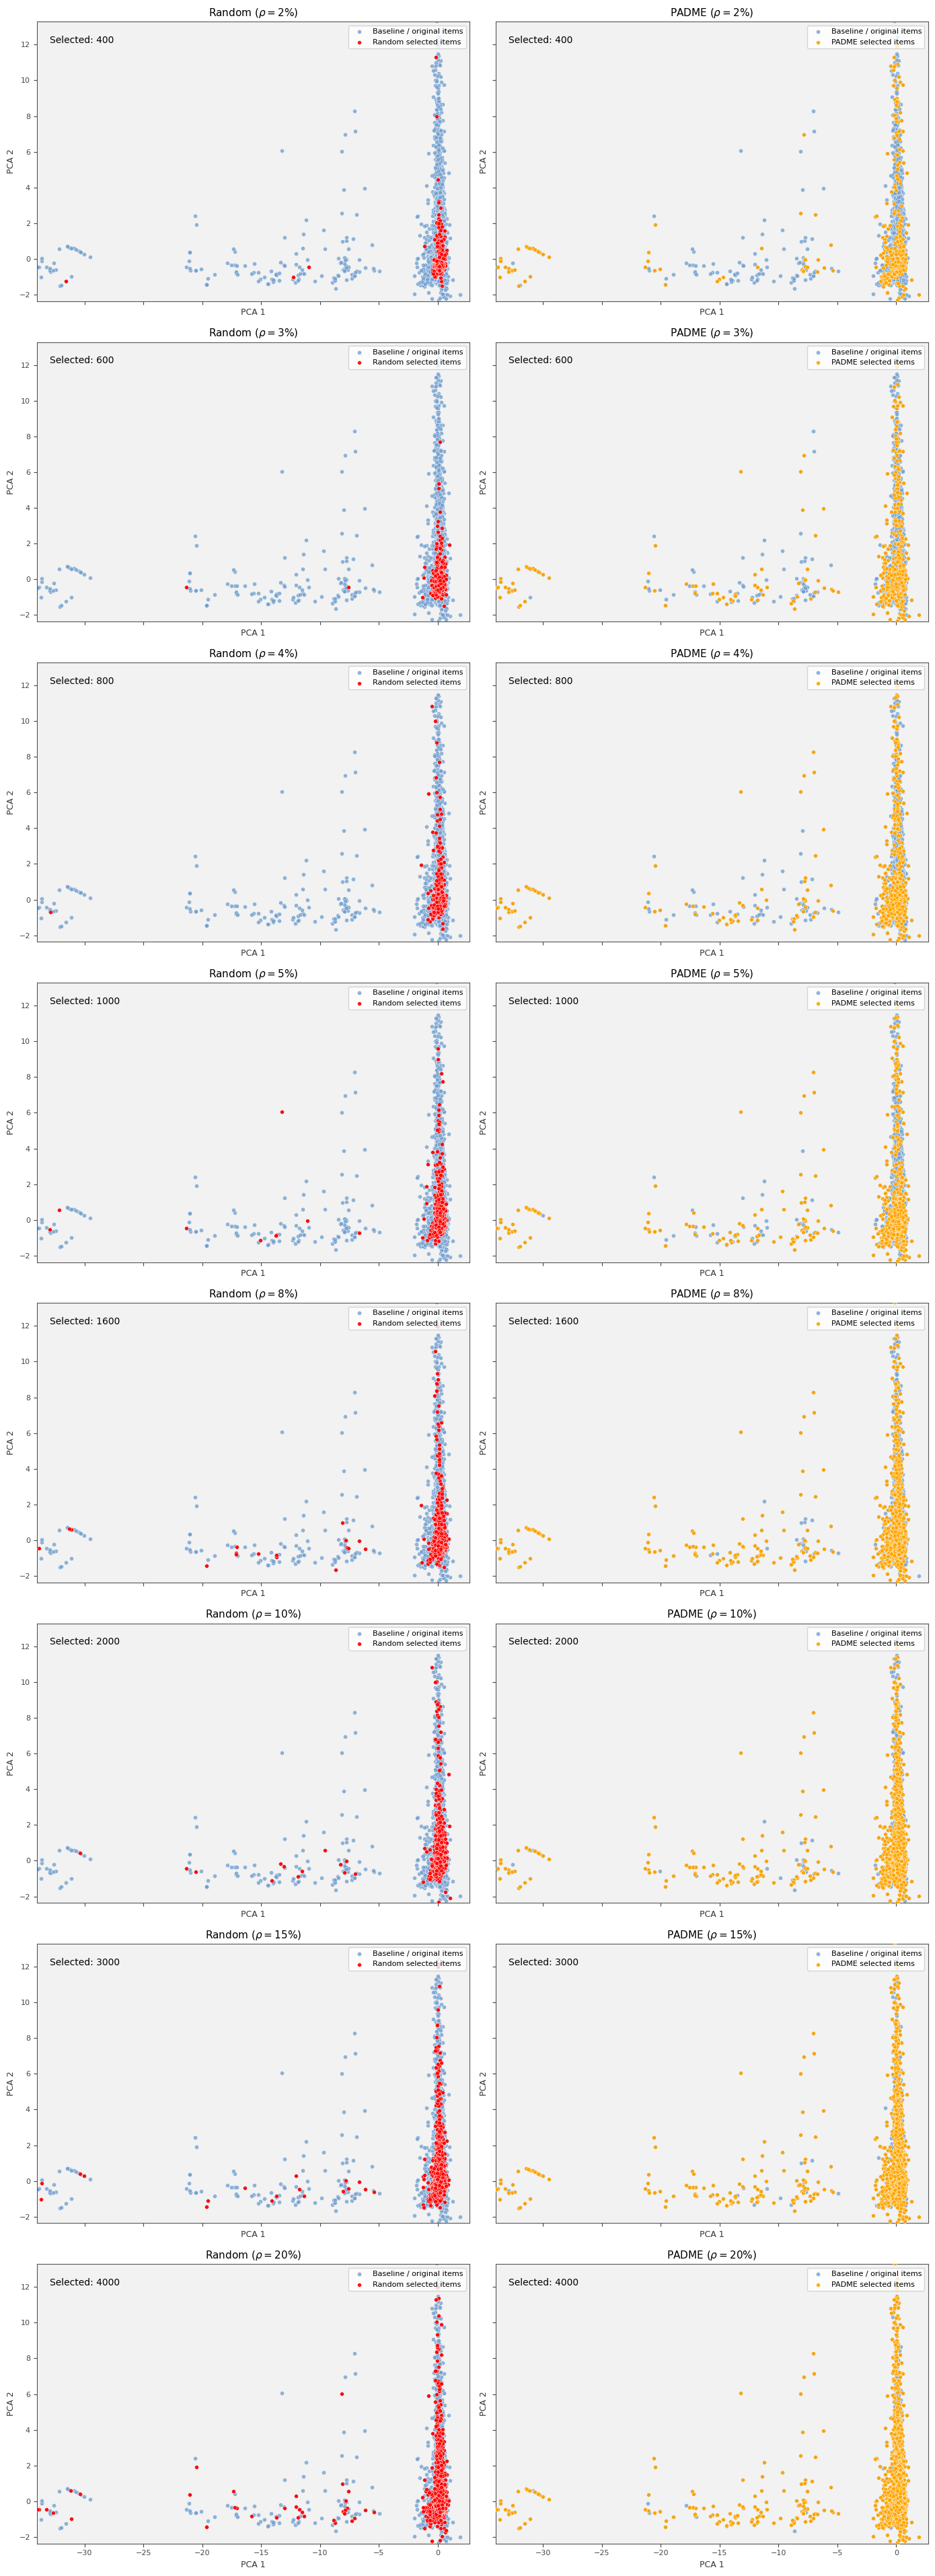

In [15]:
from matplotlib import rcParams

plt.rcdefaults()
plt.style.use("default")

rcParams["figure.facecolor"] = "white"
rcParams["axes.facecolor"] = "#f5f5f5"
rcParams["savefig.facecolor"] = "white"
rcParams["text.color"] = "black"
rcParams["axes.labelcolor"] = "black"
rcParams["axes.edgecolor"] = "#444444"
rcParams["xtick.color"] = "#444444"
rcParams["ytick.color"] = "#444444"
rcParams["legend.facecolor"] = "white"
rcParams["legend.edgecolor"] = "#cccccc"

baseline_path = OUT_DIR / "baseline" / "baseline_node0.csv"


def _load_geom_matrix(path):
    df = load_csv_any(path)
    X = df.drop(columns=[c for c in [LABEL_COL] + DROP_COLS if c in df.columns], errors="ignore")
    X = X.reindex(columns=feature_cols, fill_value=0.0)
    X = X.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return df, X


def _fit_pca_reference(X_base):
    Xb = X_base.to_numpy(dtype=float)
    scaler = StandardScaler()
    Xb_scaled = scaler.fit_transform(Xb)
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    B = pca.fit_transform(Xb_scaled)
    return scaler, pca, B


def _project_subset(X, scaler, pca):
    Xs = X.to_numpy(dtype=float)
    Xs_scaled = scaler.transform(Xs)
    Z = pca.transform(Xs_scaled)
    return Z


def _robust_limits(*arrays, low=0.5, high=99.5, pad=0.06):
    x = np.concatenate([a[:, 0] for a in arrays if len(a) > 0])
    y = np.concatenate([a[:, 1] for a in arrays if len(a) > 0])
    x0, x1 = np.percentile(x, [low, high])
    y0, y1 = np.percentile(y, [low, high])
    dx = max(1e-9, x1 - x0)
    dy = max(1e-9, y1 - y0)
    return ((x0 - pad * dx, x1 + pad * dx), (y0 - pad * dy, y1 + pad * dy))


def _draw_panel(ax, B, S, title, selected_label, selected_color, xlim, ylim, base_s, selected_s):
    ax.set_facecolor("#f2f2f2")

    ax.scatter(
        B[:, 0], B[:, 1],
        s=base_s,
        alpha=0.78,
        color="#729fcf",
        edgecolors="white",
        linewidths=0.35,
        label="Baseline / original items",
        zorder=1
    )

    ax.scatter(
        S[:, 0], S[:, 1],
        s=selected_s,
        alpha=0.92,
        color=selected_color,
        edgecolors="white",
        linewidths=0.35,
        label=selected_label,
        zorder=3
    )

    ax.text(
        0.03, 0.95,
        f"Selected: {len(S)}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        color="black"
    )

    ax.set_title(title, fontsize=11, color="black")
    ax.set_xlabel("PCA 1", fontsize=9, color="#333333")
    ax.set_ylabel("PCA 2", fontsize=9, color="#333333")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=8, colors="#444444")
    ax.legend(frameon=True, loc="upper right", fontsize=8)

    for spine in ax.spines.values():
        spine.set_color("#555555")
        spine.set_linewidth(0.8)


def _available_ratios(mode_dir):
    ratios = []
    if not mode_dir.exists():
        return ratios
    for child in mode_dir.iterdir():
        if not child.is_dir():
            continue
        try:
            ratio_int = int(child.name)
            ratios.append(ratio_int / 100.0)
        except ValueError:
            pass
    return sorted(ratios)


def _node_file_for_ratio(mode, ratio):
    ratio_dir = OUT_DIR / mode / str(ratio_to_int(ratio))
    return ratio_dir / f"{mode}_node0.csv"


df_base, X_base = _load_geom_matrix(baseline_path)
scaler, pca, B = _fit_pca_reference(X_base)

random_ratios = set(_available_ratios(OUT_DIR / "random"))
padme_ratios = set(_available_ratios(OUT_DIR / "padme"))
target_ratios = [0.02, 0.03, 0.04, 0.05, 0.08, 0.10, 0.15, 0.20]
ratios = [r for r in target_ratios if r in random_ratios and r in padme_ratios]

proj_random = {}
proj_padme = {}
all_arrays = [B]

for ratio in ratios:
    random_path = _node_file_for_ratio("random", ratio)
    padme_path = _node_file_for_ratio("padme", ratio)

    if not random_path.exists() or not padme_path.exists():
        continue

    _, X_rand = _load_geom_matrix(random_path)
    _, X_padm = _load_geom_matrix(padme_path)

    R = _project_subset(X_rand, scaler, pca)
    P = _project_subset(X_padm, scaler, pca)

    proj_random[ratio] = R
    proj_padme[ratio] = P
    all_arrays.extend([R, P])

ratios = [r for r in ratios if r in proj_random and r in proj_padme]
xlim, ylim = _robust_limits(*all_arrays, low=0.5, high=99.5, pad=0.06)

n_rows = len(ratios)
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4.8 * n_rows), sharex=True, sharey=True)
fig.patch.set_facecolor("white")

if n_rows == 1:
    axes = np.array([axes])

selected_s = 18
base_s = selected_s * 1.1

for i, ratio in enumerate(ratios):
    R = proj_random[ratio]
    P = proj_padme[ratio]
    pct = int(round(ratio * 100))

    _draw_panel(axes[i, 0], B, R, rf"Random ($\rho = {pct}\%$)", "Random selected items", "#FF0000", xlim, ylim, base_s, selected_s)
    _draw_panel(axes[i, 1], B, P, rf"PADME ($\rho = {pct}\%$)", "PADME selected items", "#FFA500", xlim, ylim, base_s, selected_s)

plt.tight_layout()
plt.show()

In [16]:
models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="saga",
            max_iter=5000,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ])
}

In [17]:
def eval_auc_metrics(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)

    pr_auc = average_precision_score(y_test, p)
    roc_auc = roc_auc_score(y_test, p)

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()

    return pr_auc, roc_auc, tp, fp, tn, fn

rows = []

for model_name, model in models.items():
    Xb, yb, pb = load_node_dataset("baseline", None, BASELINE_NODE)
    base_pr_auc, base_roc_auc, base_tp, base_fp, base_tn, base_fn = eval_auc_metrics(
        model, Xb, yb, X_test, y_test
    )

    rows.append({
        "model": model_name,
        "mode": "baseline",
        "keep_ratio": 1.0,
        "ratio_int": 100,
        "node": BASELINE_NODE,
        "tp": int(base_tp),
        "fp": int(base_fp),
        "tn": int(base_tn),
        "fn": int(base_fn),
        "pr_auc": base_pr_auc,
        "roc_auc": base_roc_auc,
        "pr_auc_mean": base_pr_auc,
        "pr_auc_std": 0.0,
        "roc_auc_mean": base_roc_auc,
        "roc_auc_std": 0.0
    })

    for mode in ["random", "padme"]:
        for r in RATIOS:
            pr_scores = []
            roc_scores = []

            tp_sum = 0
            fp_sum = 0
            tn_sum = 0
            fn_sum = 0

            for i in range(NODES):
                Xn, yn, pn = load_node_dataset(mode, r, i)
                pr_s, roc_s, tp, fp, tn, fn = eval_auc_metrics(model, Xn, yn, X_test, y_test)

                pr_scores.append(pr_s)
                roc_scores.append(roc_s)

                tp_sum += int(tp)
                fp_sum += int(fp)
                tn_sum += int(tn)
                fn_sum += int(fn)

                rows.append({
                    "model": model_name,
                    "mode": mode,
                    "keep_ratio": r,
                    "ratio_int": ratio_to_int(r),
                    "node": i,
                    "tp": int(tp),
                    "fp": int(fp),
                    "tn": int(tn),
                    "fn": int(fn),
                    "pr_auc": pr_s,
                    "roc_auc": roc_s,
                    "file": pn
                })

            rows.append({
                "model": model_name,
                "mode": mode,
                "keep_ratio": r,
                "ratio_int": ratio_to_int(r),
                "node": "mean",
                "tp": tp_sum,
                "fp": fp_sum,
                "tn": tn_sum,
                "fn": fn_sum,
                "pr_auc": float(np.mean(pr_scores)),
                "roc_auc": float(np.mean(roc_scores)),
                "pr_auc_mean": float(np.mean(pr_scores)),
                "pr_auc_std": float(np.std(pr_scores, ddof=1)) if len(pr_scores) > 1 else 0.0,
                "roc_auc_mean": float(np.mean(roc_scores)),
                "roc_auc_std": float(np.std(roc_scores, ddof=1)) if len(roc_scores) > 1 else 0.0
            })

results = pd.DataFrame(rows)

results[(results["node"] == "mean") | (results["mode"] == "baseline")].sort_values(["model", "mode", "keep_ratio"])

,model,mode,keep_ratio,ratio_int,node,tp,fp,tn,fn,pr_auc,roc_auc,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,file
0,LogReg,baseline,1.00,100,0,32,4,3956,8,0.805356,0.979223,0.805356,0.000000,0.979223,0.000000,NaN
90,LogReg,padme,0.02,2,mean,147,15,19785,53,0.796347,0.971979,0.796347,0.008668,0.971979,0.004709,NaN
96,LogReg,padme,0.03,3,mean,145,11,19789,55,0.801189,0.973933,0.801189,0.004030,0.973933,0.002740,NaN
102,LogReg,padme,0.04,4,mean,148,16,19784,52,0.801165,0.971657,0.801165,0.004034,0.971657,0.004074,NaN
108,LogReg,padme,0.05,5,mean,147,12,19788,53,0.803283,0.967601,0.803283,0.004726,0.967601,0.008903,NaN
114,LogReg,padme,0.08,8,mean,145,11,19789,55,0.804886,0.976442,0.804886,0.003178,0.976442,0.006497,NaN
120,LogReg,padme,0.10,10,mean,149,16,19784,51,0.802949,0.976801,0.802949,0.006020,0.976801,0.003831,NaN
126,LogReg,padme,0.15,15,mean,150,15,19785,50,0.806939,0.978400,0.806939,0.006094,0.978400,0.004280,NaN
132,LogReg,padme,0.20,20,mean,153,16,19784,47,0.805855,0.974894,0.805855,0.002822,0.974894,0.007634,NaN
138,LogReg,padme,0.30,30,mean,154,19,19781,46,0.808247,0.975360,0.808247,0.002483,0.975360,0.002117,NaN


In [18]:
cm_mean = (
    results[
        results["node"].apply(lambda x: isinstance(x, (int, np.integer)))
    ][["model", "mode", "keep_ratio", "tp", "fp", "tn", "fn"]]
    .groupby(["model", "mode", "keep_ratio"], as_index=False)
    .mean()
)

cm_mean["precision"] = cm_mean["tp"] / (cm_mean["tp"] + cm_mean["fp"])
cm_mean["recall"] = cm_mean["tp"] / (cm_mean["tp"] + cm_mean["fn"])

cm_mean["precision"] = cm_mean["precision"].fillna(0.0)
cm_mean["recall"] = cm_mean["recall"].fillna(0.0)

cm_mean = cm_mean.sort_values(["model", "mode", "keep_ratio"]).reset_index(drop=True)

for model in cm_mean["model"].unique():
    print(f"\n=== {model} ===")
    sub_model = cm_mean[cm_mean["model"] == model]

    for mode in sub_model["mode"].unique():
        print(f"\n-- {mode} --")
        sub_mode = sub_model[sub_model["mode"] == mode]

        for _, r in sub_mode.iterrows():
            print(
                f"keep_ratio={r['keep_ratio']:.2f} | "
                f"tp={r['tp']:.1f} fp={r['fp']:.1f} tn={r['tn']:.1f} fn={r['fn']:.1f} | "
                f"precision={r['precision']:.4f} recall={r['recall']:.4f}"
            )


=== LogReg ===

-- baseline --
keep_ratio=1.00 | tp=32.0 fp=4.0 tn=3956.0 fn=8.0 | precision=0.8889 recall=0.8000

-- padme --
keep_ratio=0.02 | tp=29.4 fp=3.0 tn=3957.0 fn=10.6 | precision=0.9074 recall=0.7350
keep_ratio=0.03 | tp=29.0 fp=2.2 tn=3957.8 fn=11.0 | precision=0.9295 recall=0.7250
keep_ratio=0.04 | tp=29.6 fp=3.2 tn=3956.8 fn=10.4 | precision=0.9024 recall=0.7400
keep_ratio=0.05 | tp=29.4 fp=2.4 tn=3957.6 fn=10.6 | precision=0.9245 recall=0.7350
keep_ratio=0.08 | tp=29.0 fp=2.2 tn=3957.8 fn=11.0 | precision=0.9295 recall=0.7250
keep_ratio=0.10 | tp=29.8 fp=3.2 tn=3956.8 fn=10.2 | precision=0.9030 recall=0.7450
keep_ratio=0.15 | tp=30.0 fp=3.0 tn=3957.0 fn=10.0 | precision=0.9091 recall=0.7500
keep_ratio=0.20 | tp=30.6 fp=3.2 tn=3956.8 fn=9.4 | precision=0.9053 recall=0.7650
keep_ratio=0.30 | tp=30.8 fp=3.8 tn=3956.2 fn=9.2 | precision=0.8902 recall=0.7700
keep_ratio=0.40 | tp=31.2 fp=4.4 tn=3955.6 fn=8.8 | precision=0.8764 recall=0.7800
keep_ratio=0.50 | tp=31.0 fp=4.0 tn

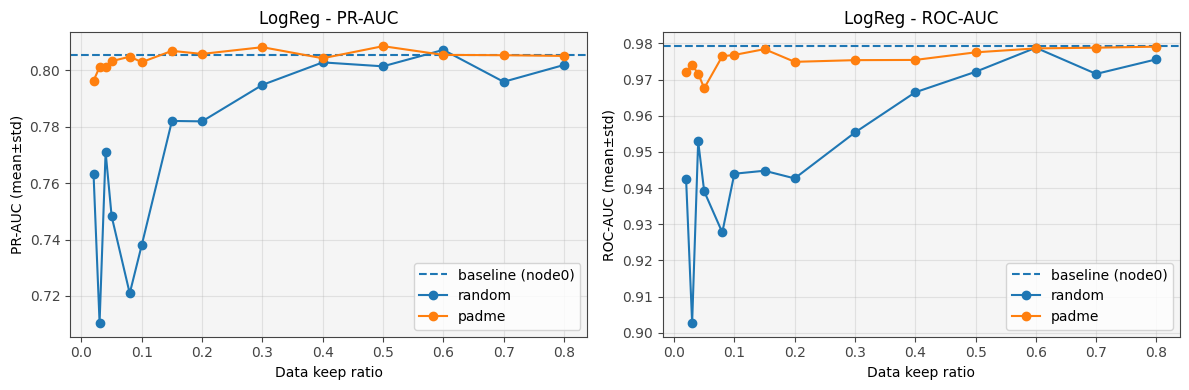

In [19]:
for model_name in models.keys():
    sub_mean = results[(results["model"] == model_name) & (results["node"] == "mean")].copy()
    base_row = results[(results["model"] == model_name) & (results["mode"] == "baseline")].iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    metrics = [
        ("pr_auc", "PR-AUC"),
        ("roc_auc", "ROC-AUC"),
    ]

    for ax, (metric_key, metric_label) in zip(axes, metrics):
        base = base_row[f"{metric_key}_mean"]
        ax.axhline(base, linestyle="--", label=f"baseline (node{BASELINE_NODE})")

        for mode in ["random", "padme"]:
            s = sub_mean[sub_mean["mode"] == mode].sort_values("keep_ratio")
            ax.errorbar(
                s["keep_ratio"],
                s[f"{metric_key}_mean"],
                #yerr=s[f"{metric_key}_std"],
                marker="o",
                capsize=3,
                label=mode
            )

        ax.set_xlabel("Data keep ratio")
        ax.set_ylabel(f"{metric_label} (mean±std)")
        ax.set_title(f"{model_name} - {metric_label}")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()